In [ ]:
# RAPIDO RIDES - Google Colab Notebook Script
# Purpose: Upload rides_data.csv -> load into MySQL -> run EDA and export results
# Instructions: Paste into Google Colab. Replace MySQL connection details when prompted.

# ---------------------------
# 0) Install & import packages
# ---------------------------
!pip install --quiet sqlalchemy pymysql pandas matplotlib sqlalchemy-utils

import os
import getpass
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
from sqlalchemy_utils import database_exists, create_database
import pymysql
from datetime import datetime
from google.colab import files

# Make plots display inline
%matplotlib inline

In [ ]:
# ---------------------------
# 1) Upload CSV to Colab
# ---------------------------
print("Upload your rides_data.csv when the upload dialog appears.")
uploaded = files.upload()
if not uploaded:
    raise SystemExit("No file uploaded — re-run and upload rides_data.csv")

csv_filename = list(uploaded.keys())[0]
print(f"Uploaded file: {csv_filename} (size: {os.path.getsize(csv_filename)} bytes)")

Upload your rides_data.csv when the upload dialog appears.


Saving rides_data.csv to rides_data (1).csv
Uploaded file: rides_data (1).csv (size: 6998303 bytes)


In [ ]:
# ---------------------------
# 2) Preview CSV locally (quick)
# ---------------------------
# Read a small sample first to inspect structure
df_preview = pd.read_csv(csv_filename, nrows=100)
print("Columns detected:", df_preview.columns.tolist())
display(df_preview.head())

Columns detected: ['services', 'date', 'time', 'ride_status', 'source', 'destination', 'duration', 'ride_id', 'distance', 'ride_charge', 'misc_charge', 'total_fare', 'payment_method']


,services,date,time,ride_status,source,destination,duration,ride_id,distance,ride_charge,misc_charge,total_fare,payment_method
0,cab economy,2024-07-15,08:30:40.542646,completed,Balagere Harbor,Harohalli Nagar,39,RD3161218751875354,27.21,764.83,31.51,796.34,Amazon Pay
1,auto,2024-07-05,23:36:51.542646,completed,Basavanagudi 3rd Block,Bikasipura 1st Stage,89,RD8171514284594096,34.03,314.83,49.52,364.35,Paytm
2,auto,2024-07-23,11:05:37.542646,cancelled,Babusapalya Cove,Kothaguda Terrace,25,RD9376481122237926,20.24,NaN,NaN,NaN,NaN
3,cab economy,2024-06-24,08:45:10.542646,completed,Mahadevapura Mews,Kanakapura Arc,89,RD3676889143182765,31.17,484.73,15.84,500.57,QR scan
4,cab economy,2024-07-15,00:26:44.542646,completed,Ganganagar Cove,Basaveshwaranagar Colony,95,RD6639410275948084,27.21,663.50,14.13,677.63,Amazon Pay


In [ ]:
import sqlite3, pandas as pd
conn = sqlite3.connect("rides_data.db")
df = pd.read_csv("/content/rides_data.csv")
df.to_sql("rides_data", conn, index=False, if_exists="replace")
pd.read_sql("SELECT COUNT(*) FROM rides_data;", conn)


,COUNT(*)
0,50000


In [ ]:
# -------------------------------------------------
# 3 — Verify data & show sample
# -------------------------------------------------
import pandas as pd

# View first 10 rows from SQLite
sample_df = pd.read_sql("SELECT * FROM rides_data LIMIT 10;", conn)
print("Sample Data from rides_data:")
display(sample_df)

# Check table info (row count, columns)
row_count = pd.read_sql("SELECT COUNT(*) AS total_rows FROM rides_data;", conn)
print("\nTotal rows:", row_count['total_rows'][0])
print("\nColumns:", list(sample_df.columns))

✅ Sample Data from rides_data:


,services,date,time,ride_status,source,destination,duration,ride_id,distance,ride_charge,misc_charge,total_fare,payment_method
0,cab economy,2024-07-15,08:30:40.542646,completed,Balagere Harbor,Harohalli Nagar,39,RD3161218751875354,27.21,764.83,31.51,796.34,Amazon Pay
1,auto,2024-07-05,23:36:51.542646,completed,Basavanagudi 3rd Block,Bikasipura 1st Stage,89,RD8171514284594096,34.03,314.83,49.52,364.35,Paytm
2,auto,2024-07-23,11:05:37.542646,cancelled,Babusapalya Cove,Kothaguda Terrace,25,RD9376481122237926,20.24,NaN,NaN,NaN,None
3,cab economy,2024-06-24,08:45:10.542646,completed,Mahadevapura Mews,Kanakapura Arc,89,RD3676889143182765,31.17,484.73,15.84,500.57,QR scan
4,cab economy,2024-07-15,00:26:44.542646,completed,Ganganagar Cove,Basaveshwaranagar Colony,95,RD6639410275948084,27.21,663.50,14.13,677.63,Amazon Pay
5,auto,2024-07-02,01:28:29.542646,completed,HSR Layout Area,JP Nagar Viewpoint,18,RD5922205486441934,33.69,456.73,25.19,481.92,QR scan
6,cab economy,2024-07-23,20:55:28.542646,completed,Arekere Heights,Dooravani Nagar Pointe,85,RD9557099396888459,20.44,836.39,14.95,851.34,GPay
7,parcel,2024-07-18,13:38:33.542646,completed,Electronic City Village,Ganganagar Station,89,RD9473873953525644,35.31,724.76,31.34,756.10,QR scan
8,parcel,2024-08-08,07:59:53.542646,completed,Mysore Road Lane,Billekahalli 6th Block,72,RD1285566012167240,45.99,641.55,21.48,663.03,Amazon Pay
9,bike lite,2024-07-10,12:30:07.542646,completed,Kundalahalli Alley,RT Nagar 5th Block,94,RD7238628094142076,44.43,571.50,47.63,619.13,QR scan



Total rows: 50000

Columns: ['services', 'date', 'time', 'ride_status', 'source', 'destination', 'duration', 'ride_id', 'distance', 'ride_charge', 'misc_charge', 'total_fare', 'payment_method']


In [ ]:
# -------------------------------------------------
# 4 — Basic SQL queries (Data Extraction)
# -------------------------------------------------
# Example 1: Total completed vs cancelled rides
ride_status_summary = pd.read_sql("""
SELECT ride_status, COUNT(*) AS total_rides
FROM rides_data
GROUP BY ride_status
ORDER BY total_rides DESC;
""", conn)
print("\n✅ Ride Status Summary:")
display(ride_status_summary)

# Example 2: Average fare per service
avg_fare_service = pd.read_sql("""
SELECT services, ROUND(AVG(total_fare),2) AS avg_fare
FROM rides_data
WHERE total_fare IS NOT NULL
GROUP BY services
ORDER BY avg_fare DESC;
""", conn)
print("\n✅ Average Fare per Service:")
display(avg_fare_service)

# Example 3: Top 10 routes by count
top_routes = pd.read_sql("""
SELECT source, destination, COUNT(*) AS total_rides
FROM rides_data
GROUP BY source, destination
ORDER BY total_rides DESC
LIMIT 10;
""", conn)
print("\n✅ Top 10 Routes:")
display(top_routes)



✅ Ride Status Summary:


,ride_status,total_rides
0,completed,44964
1,cancelled,5036



✅ Average Fare per Service:


,services,avg_fare
0,auto,548.83
1,bike,547.86
2,cab economy,547.25
3,parcel,546.39
4,bike lite,544.15



✅ Top 10 Routes:


,source,destination,total_rides
0,Anekal Woods,Yelahanka Complex,2
1,Basaveshwaranagar Place,Kalena Agrahara Fork,2
2,HSR Layout Crescent,Tavarekere View,2
3,Jayanagar Cut,Yelahanka Landing,2
4,Kundalahalli 6th Stage,Gottigere 5th Stage,2
5,Magadi Road 5th Stage,Rachenahalli Landing,2
6,Naganathapura Close,Koramangala 7th Block Vista,2
7,Adugodi 1st Stage,Babusapalya Estate,1
8,Adugodi 1st Stage,Horamavu Banaswadi Cutting,1
9,Adugodi 1st Stage,Indiranagar Cross,1


/tmp/ipython-input-2881964739.py:11: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



✅ Missing Values:


,0
payment_method,5036
ride_charge,5036
misc_charge,5036
total_fare,5036
services,0
source,0
ride_status,0
time,0
date,0
distance,0


,duration,distance,ride_charge,misc_charge,total_fare
count,50000.000000,50000.000000,44964.000000,44964.000000,44964.000000
mean,64.320100,25.528243,522.428805,24.964289,547.393093
std,31.852336,14.177136,274.726031,14.459417,275.094813
min,10.000000,1.000000,50.030000,0.000000,50.580000
25%,37.000000,13.260000,283.657500,12.400000,308.920000
50%,64.000000,25.460000,520.030000,25.070000,544.920000
75%,92.000000,37.860000,759.367500,37.510000,785.502500
max,119.000000,50.000000,999.960000,50.000000,1048.800000


/tmp/ipython-input-2881964739.py:24: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




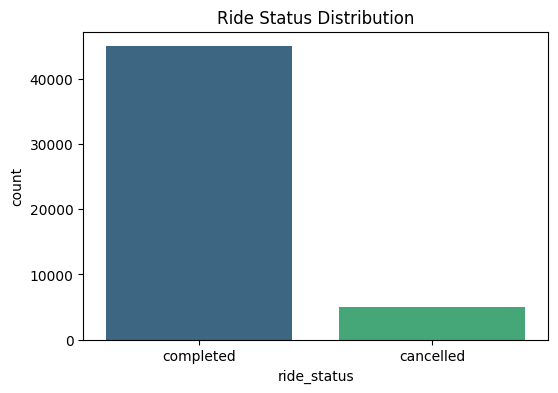

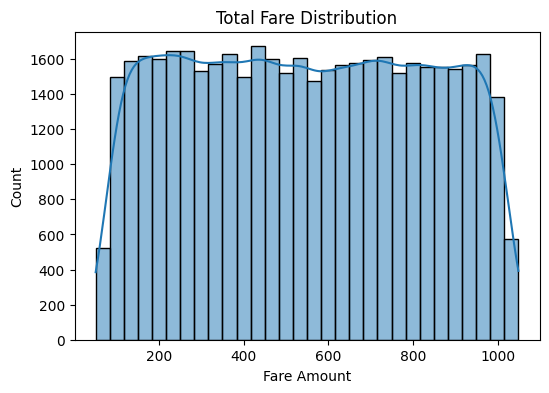

In [ ]:
# -------------------------------------------------
# 5 — Data Cleaning & EDA in Python (pandas)
# -------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convert date/time columns properly
df = pd.read_sql("SELECT * FROM rides_data;", conn)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['time'] = pd.to_datetime(df['time'], errors='coerce').dt.time

# Check missing values
print("✅ Missing Values:")
missing = df.isnull().sum().sort_values(ascending=False)
display(missing)

# Describe numeric columns
numeric_cols = ['duration', 'distance', 'ride_charge', 'misc_charge', 'total_fare']
display(df[numeric_cols].describe())

# Plot ride_status distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='ride_status', palette='viridis')
plt.title("Ride Status Distribution")
plt.show()

# Plot total fare distribution
plt.figure(figsize=(6,4))
sns.histplot(df['total_fare'], bins=30, kde=True)
plt.title("Total Fare Distribution")
plt.xlabel("Fare Amount")
plt.show()


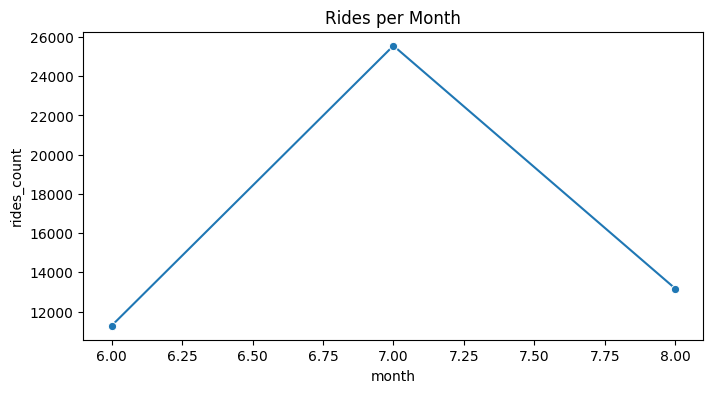

/tmp/ipython-input-2068727792.py:23: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




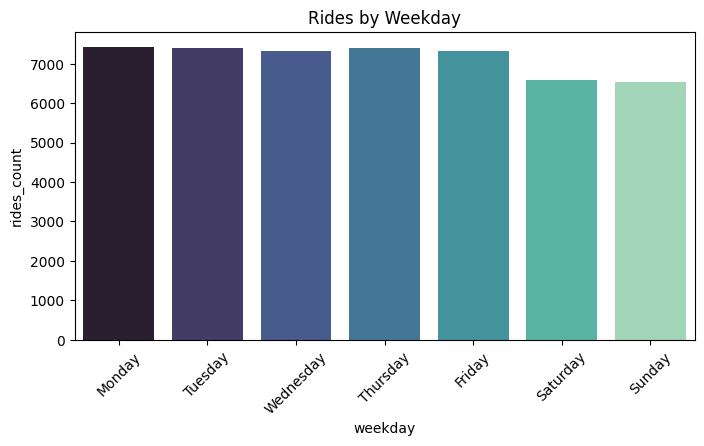

In [ ]:
# -------------------------------------------------
# 6 — Time-based Insights
# -------------------------------------------------
# Extract month, weekday, and hour
df['month'] = df['date'].dt.month
df['weekday'] = df['date'].dt.day_name()

# Rides per month
rides_per_month = df.groupby('month').size().reset_index(name='rides_count')

plt.figure(figsize=(8,4))
sns.lineplot(data=rides_per_month, x='month', y='rides_count', marker='o')
plt.title("Rides per Month")
plt.show()

# Rides by weekday
rides_by_weekday = df.groupby('weekday').size().reset_index(name='rides_count')
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
rides_by_weekday['weekday'] = pd.Categorical(rides_by_weekday['weekday'], categories=weekday_order, ordered=True)
rides_by_weekday = rides_by_weekday.sort_values('weekday')

plt.figure(figsize=(8,4))
sns.barplot(data=rides_by_weekday, x='weekday', y='rides_count', palette='mako')
plt.title("Rides by Weekday")
plt.xticks(rotation=45)
plt.show()


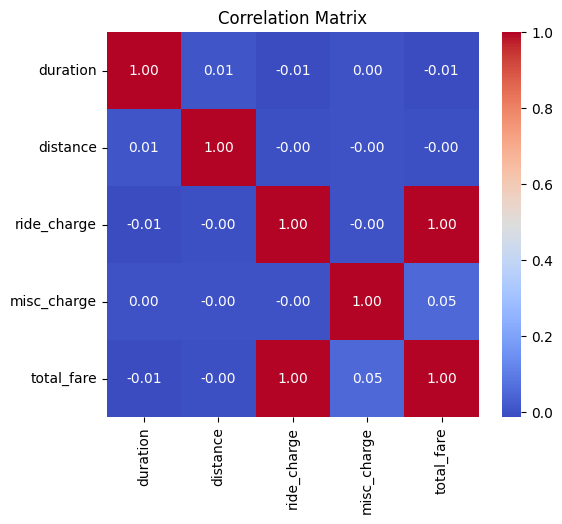

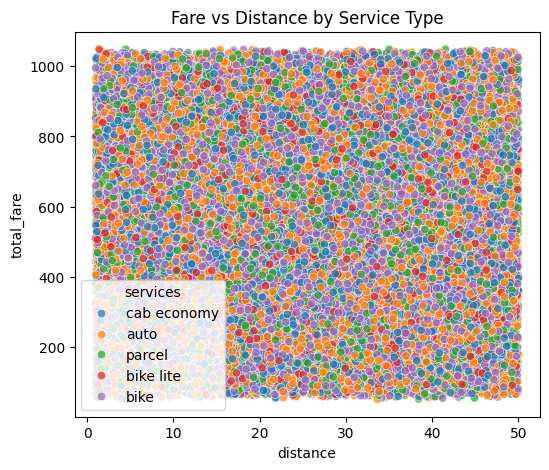

In [ ]:
# -------------------------------------------------
# 7 — Relationship Analysis
# -------------------------------------------------
# Correlation heatmap
plt.figure(figsize=(6,5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Fare vs Distance scatter plot
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='distance', y='total_fare', hue='services', alpha=0.7)
plt.title("Fare vs Distance by Service Type")
plt.show()


In [ ]:
# -------------------------------------------------
# 8 — Advanced Aggregations
# -------------------------------------------------
# Average fare and distance by ride_status
fare_distance_status = df.groupby('ride_status')[['distance','total_fare']].mean().round(2).reset_index()
print("✅ Average Distance and Fare by Ride Status:")
display(fare_distance_status)

# Average fare per payment method
avg_fare_payment = df.groupby('payment_method')['total_fare'].mean().sort_values(ascending=False).round(2)
print("\n✅ Average Fare by Payment Method:")
display(avg_fare_payment)

# Cancellation rate per service
cancel_rate = df.groupby('services').apply(lambda g: (g['ride_status']=='cancelled').mean()*100).reset_index(name='cancel_rate_%')
print("\n✅ Cancellation Rate per Service:")
display(cancel_rate)


✅ Average Distance and Fare by Ride Status:


,ride_status,distance,total_fare
0,cancelled,25.78,NaN
1,completed,25.50,547.39



✅ Average Fare by Payment Method:


,total_fare
payment_method,
Paytm,548.05
GPay,547.66
QR scan,547.61
Amazon Pay,546.25



✅ Cancellation Rate per Service:


/tmp/ipython-input-710331689.py:15: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,services,cancel_rate_%
0,auto,9.840188
1,bike,10.318614
2,bike lite,10.155610
3,cab economy,10.331308
4,parcel,9.545515


In [ ]:
# -------------------------------------------------
# 9 — Save Insights for Power BI or Reporting
# -------------------------------------------------
# Save processed data & summaries
df.to_csv("rides_data_cleaned.csv", index=False)
ride_status_summary.to_csv("ride_status_summary.csv", index=False)
avg_fare_service.to_csv("avg_fare_service.csv", index=False)
top_routes.to_csv("top_routes.csv", index=False)
cancel_rate.to_csv("cancel_rate.csv", index=False)

print("✅ Exported all summary CSVs successfully!")


✅ Exported all summary CSVs successfully!


🚨 Total Fare Outliers: 0


,services,date,time,ride_status,source,destination,duration,ride_id,distance,ride_charge,misc_charge,total_fare,payment_method,month,weekday


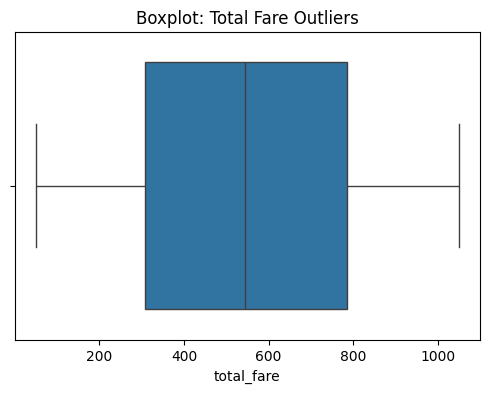

⚠️ Suspicious low fares (fare < ₹50 but long rides): 0


,services,date,time,ride_status,source,destination,duration,ride_id,distance,ride_charge,misc_charge,total_fare,payment_method,month,weekday


In [ ]:
# -------------------------------------------------
# 10 — ADVANCED EDA: Outliers & Anomalies
# -------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numeric columns again
numeric_cols = ['duration', 'distance', 'ride_charge', 'misc_charge', 'total_fare']

# Function to detect outliers using IQR
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return df[(df[column] < lower) | (df[column] > upper)]

# Detect anomalies in total_fare
outliers_fare = detect_outliers(df, 'total_fare')
print("🚨 Total Fare Outliers:", len(outliers_fare))
display(outliers_fare.head(5))

plt.figure(figsize=(6,4))
sns.boxplot(x=df['total_fare'])
plt.title("Boxplot: Total Fare Outliers")
plt.show()

# Detect rides where fare < 50 but duration > 60 mins
weird_fares = df[(df['total_fare'] < 50) & (df['duration'] > 60)]
print("⚠️ Suspicious low fares (fare < ₹50 but long rides):", len(weird_fares))
display(weird_fares.head(5))


💰 Total Revenue: ₹ 24612983.05
🎫 Average Fare: ₹ 547.39
❌ Cancellation Rate: 10.07 %


/tmp/ipython-input-449699586.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




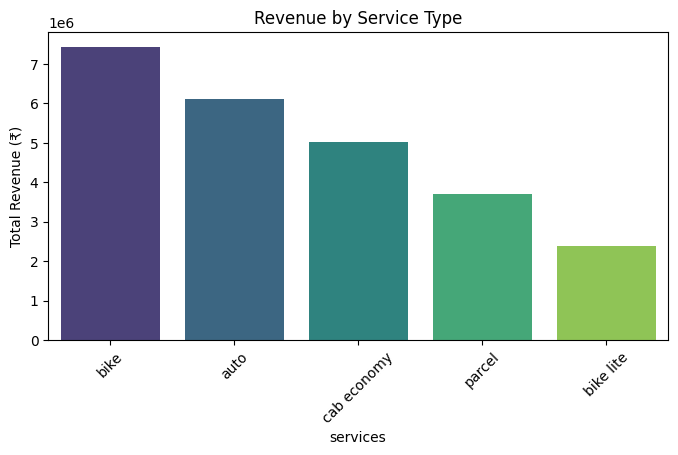

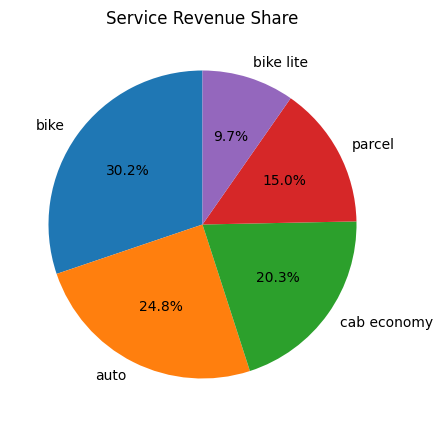

In [ ]:
# -------------------------------------------------
# 11 — BUSINESS KPIs & AGGREGATIONS
# -------------------------------------------------

# Total revenue, avg fare, cancellation rate
total_revenue = df['total_fare'].sum()
avg_fare = df['total_fare'].mean()
cancel_rate = (df['ride_status'] == 'cancelled').mean() * 100

print("💰 Total Revenue: ₹", round(total_revenue,2))
print("🎫 Average Fare: ₹", round(avg_fare,2))
print("❌ Cancellation Rate:", round(cancel_rate,2), "%")

# Revenue by service type
revenue_by_service = df.groupby('services')['total_fare'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,4))
sns.barplot(x=revenue_by_service.index, y=revenue_by_service.values, palette="viridis")
plt.title("Revenue by Service Type")
plt.ylabel("Total Revenue (₹)")
plt.xticks(rotation=45)
plt.show()

# Revenue share pie chart
plt.figure(figsize=(5,5))
revenue_by_service.plot.pie(autopct='%1.1f%%', startangle=90)
plt.title("Service Revenue Share")
plt.ylabel("")
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.



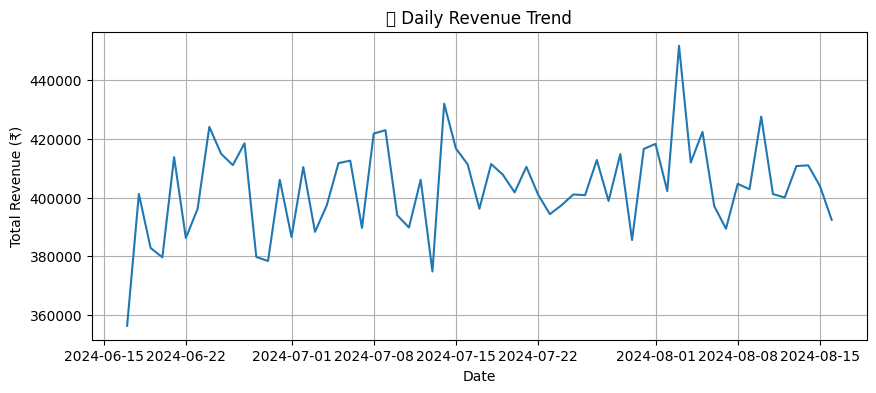

/tmp/ipython-input-3610359658.py:20: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




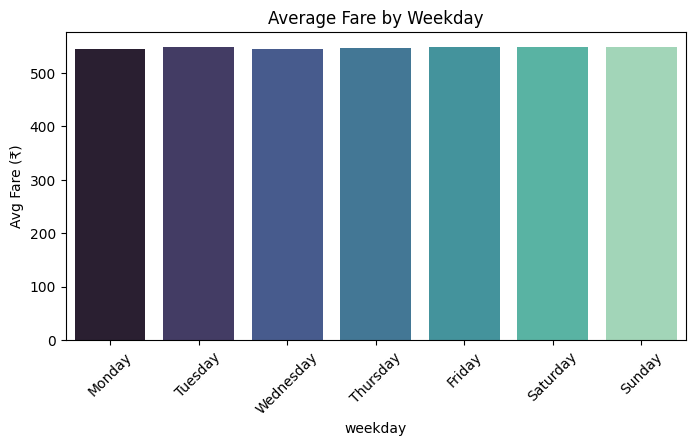

In [ ]:
# -------------------------------------------------
# 12 — TIME SERIES TRENDS
# -------------------------------------------------
# Daily revenue trend
daily_revenue = df.groupby('date')['total_fare'].sum().reset_index()

plt.figure(figsize=(10,4))
sns.lineplot(data=daily_revenue, x='date', y='total_fare')
plt.title("📅 Daily Revenue Trend")
plt.ylabel("Total Revenue (₹)")
plt.xlabel("Date")
plt.grid(True)
plt.show()

# Average fare by weekday
avg_fare_weekday = df.groupby('weekday')['total_fare'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']).reset_index()

plt.figure(figsize=(8,4))
sns.barplot(data=avg_fare_weekday, x='weekday', y='total_fare', palette='mako')
plt.title("Average Fare by Weekday")
plt.xticks(rotation=45)
plt.ylabel("Avg Fare (₹)")
plt.show()


,No_of_Rides,Avg_Fare,Total_Revenue
payment_method,,,
Amazon Pay,11225,546.25,6131641.87
GPay,11268,547.66,6171005.26
Paytm,11315,548.05,6201171.55
QR scan,11156,547.61,6109164.37


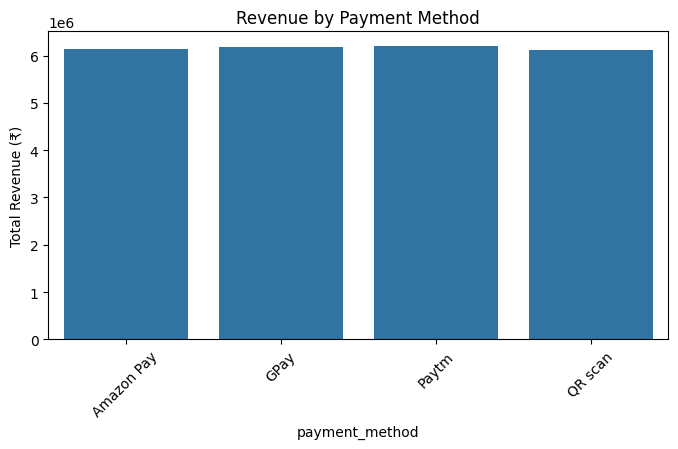

In [ ]:
# -------------------------------------------------
# 13 — PAYMENT METHOD INSIGHTS
# -------------------------------------------------
payment_summary = df.groupby('payment_method')['total_fare'].agg(['count','mean','sum']).round(2)
payment_summary = payment_summary.rename(columns={'count':'No_of_Rides','mean':'Avg_Fare','sum':'Total_Revenue'})
display(payment_summary)

plt.figure(figsize=(8,4))
sns.barplot(x=payment_summary.index, y=payment_summary['Total_Revenue'])
plt.title("Revenue by Payment Method")
plt.ylabel("Total Revenue (₹)")
plt.xticks(rotation=45)
plt.show()


🚗 Service-wise Performance Summary:


,services,distance,duration,total_fare
0,auto,25.60,64.92,548.83
1,bike,25.39,63.93,547.86
2,bike lite,25.70,64.12,544.15
3,cab economy,25.50,64.25,547.25
4,parcel,25.64,64.37,546.39


/tmp/ipython-input-1179007571.py:20: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




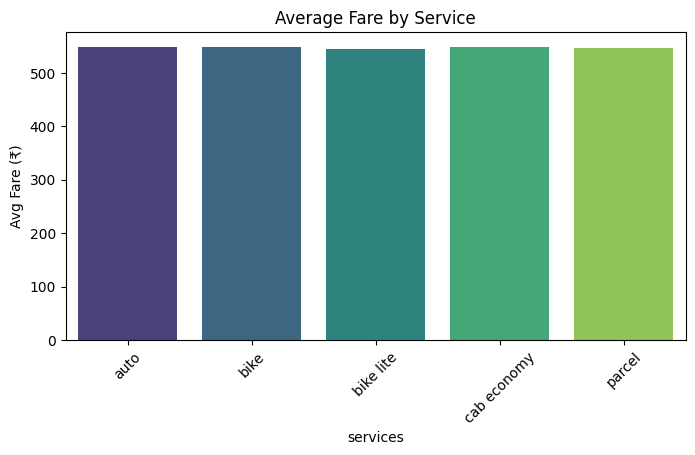

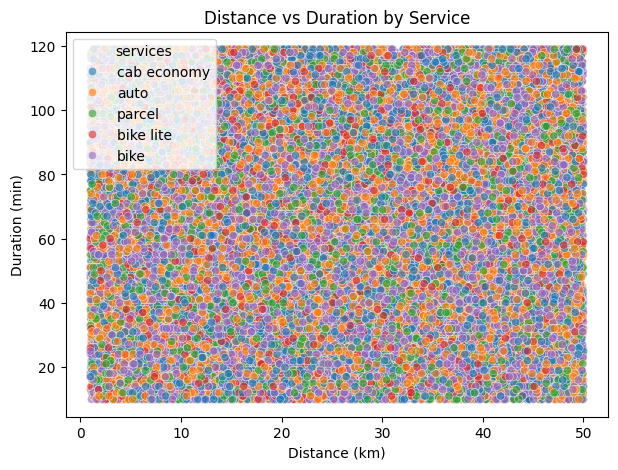

In [ ]:
# -------------------------------------------------
# 14 — SERVICE & PERFORMANCE ANALYSIS
# -------------------------------------------------
service_summary = (
    df.groupby('services')
    .agg({
        'distance': 'mean',
        'duration': 'mean',
        'total_fare': 'mean'
    })
    .round(2)
    .reset_index()
)

print("🚗 Service-wise Performance Summary:")
display(service_summary)

# Visual comparison
plt.figure(figsize=(8,4))
sns.barplot(data=service_summary, x='services', y='total_fare', palette='viridis')
plt.title("Average Fare by Service")
plt.ylabel("Avg Fare (₹)")
plt.xticks(rotation=45)
plt.show()

# Distance vs Duration relationship
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='distance', y='duration', hue='services', alpha=0.6)
plt.title("Distance vs Duration by Service")
plt.xlabel("Distance (km)")
plt.ylabel("Duration (min)")
plt.show()


/tmp/ipython-input-2132194793.py:6: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/tmp/ipython-input-2132194793.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




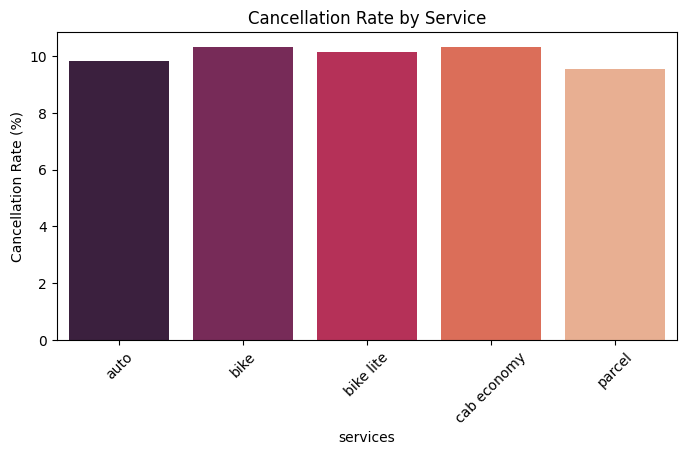

,services,cancel_rate_%
3,cab economy,10.331308
1,bike,10.318614
2,bike lite,10.155610
0,auto,9.840188
4,parcel,9.545515


In [ ]:
# -------------------------------------------------
# 15 — CANCELLATION & SERVICE INSIGHTS
# -------------------------------------------------
cancel_rate_service = (
    df.groupby('services')
    .apply(lambda g: (g['ride_status'] == 'cancelled').mean() * 100)
    .reset_index(name='cancel_rate_%')
)

plt.figure(figsize=(8,4))
sns.barplot(data=cancel_rate_service, x='services', y='cancel_rate_%', palette='rocket')
plt.title("Cancellation Rate by Service")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.show()

display(cancel_rate_service.sort_values('cancel_rate_%', ascending=False))


In [ ]:
# -------------------------------------------------
# 16 - INTERACTIVE EDA (OPTIONAL - PLOTLY)
# -------------------------------------------------
!pip install --quiet plotly
import plotly.express as px

# Interactive: Fare vs Distance
fig = px.scatter(df, x='distance', y='total_fare', color='services',
                 title='Fare vs Distance (Interactive)',
                 hover_data=['ride_status','payment_method'])
fig.show()

# Interactive: Daily Revenue Trend
fig2 = px.line(daily_revenue, x='date', y='total_fare', title='Interactive Daily Revenue Trend')
fig2.show()

# Interactive: Revenue by Payment Method
fig3 = px.bar(payment_summary, x=payment_summary.index, y='Total_Revenue',
              title='Revenue by Payment Method (Interactive)')
fig3.show()
